# Smart Transit
## AI-Powered Multimodal Journey Planner

**AI Lab - Transit BD**

This notebook develops an AI-powered multimodal journey planning system
for urban public transportation.

### Objectives

- Represent the urban transit system as a graph
- Find optimal routes between origin and destination
- Support multiple transportation modes
- Estimate journey time
- Rank alternative routes using multiple criteria
- Evaluate routing performance and prediction accuracy

# 1. Methodology

The prototype follows a simple API-to-algorithm pipeline:

```text
Location Input
      ↓
Nominatim Geocoding
      ↓
Coordinates
      ↓
OSRM Route Data
      ↓
Graph Construction
      ↓
┌──────────────────────────────┐
│ Dijkstra                     │
│ A*                           │
│ Multi-Criteria Optimization  │
│ ETA Prediction               │
└──────────────────────────────┘
      ↓
Journey Recommendation
```

The APIs provide external data; the main routing and optimization logic is implemented inside the notebook.


In [1]:
# Core libraries
import os
import math
import heapq
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import networkx as nx

warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment initialized.")

Environment initialized.


In [2]:
# Project configuration

PROJECT_NAME = "Smart Transit"
PROJECT_VERSION = "0.1.0"

TRANSPORT_MODES = [
    "bus",
    "metro",
    "walking",
    "rickshaw",
    "car"
]

OBJECTIVE_WEIGHTS = {
    "time": 0.50,
    "cost": 0.20,
    "transfers": 0.15,
    "walking": 0.15
}

print(f"Project: {PROJECT_NAME}")
print(f"Version: {PROJECT_VERSION}")
print(f"Modes: {TRANSPORT_MODES}")
print(f"Objective weights: {OBJECTIVE_WEIGHTS}")

Project: Smart Transit
Version: 0.1.0
Modes: ['bus', 'metro', 'walking', 'rickshaw', 'car']
Objective weights: {'time': 0.5, 'cost': 0.2, 'transfers': 0.15, 'walking': 0.15}


# 2. API & Data Source Configuration

The Smart Transit system uses open and freely accessible
geospatial and routing data sources.

Primary sources:

- OpenStreetMap
- Nominatim
- OSRM

These services provide the external data required by the system,
while the core routing and optimization algorithms are implemented
within the project.

In [3]:
import requests

NOMINATIM_URL = "https://nominatim.openstreetmap.org/search"
OSRM_URL = "https://router.project-osrm.org/route/v1"

print("Open-source API configuration loaded.")

Open-source API configuration loaded.


In [4]:
def geocode_location(location):
    """
    Convert a location name into latitude and longitude
    using the Nominatim API.
    """

    params = {
        "q": location,
        "format": "json",
        "limit": 1
    }

    headers = {
        "User-Agent": "SmartTransit-AI-Lab"
    }

    response = requests.get(
        NOMINATIM_URL,
        params=params,
        headers=headers,
        timeout=10
    )

    response.raise_for_status()

    data = response.json()

    if not data:
        return None

    return {
        "name": location,
        "latitude": float(data[0]["lat"]),
        "longitude": float(data[0]["lon"])
    }

In [5]:
origin = geocode_location("Farmgate, Dhaka")
destination = geocode_location("Uttara, Dhaka")

print("Origin:", origin)
print("Destination:", destination)

Origin: {'name': 'Farmgate, Dhaka', 'latitude': 23.7590394, 'longitude': 90.3871113}
Destination: {'name': 'Uttara, Dhaka', 'latitude': 23.739291, 'longitude': 90.407229}


In [6]:
destination = geocode_location("Uttara Sector 7, Dhaka")

print("Destination:", destination)

Destination: {'name': 'Uttara Sector 7, Dhaka', 'latitude': 23.8676434, 'longitude': 90.4004622}


In [7]:
def get_osrm_route(origin, destination):
    """
    Get driving route information from OSRM.
    """

    start = f"{origin['longitude']},{origin['latitude']}"
    end = f"{destination['longitude']},{destination['latitude']}"

    url = f"{OSRM_URL}/driving/{start};{end}"

    params = {
        "overview": "false"
    }

    response = requests.get(
        url,
        params=params,
        timeout=10
    )

    response.raise_for_status()

    data = response.json()

    if data["code"] != "Ok":
        return None

    route = data["routes"][0]

    return {
        "distance_km": route["distance"] / 1000,
        "duration_min": route["duration"] / 60
    }

In [8]:
route = get_osrm_route(origin, destination)

print(route)

{'distance_km': 17.4501, 'duration_min': 14.713333333333333}


### Get Route Geometry

In [9]:
def get_route_geometry(origin, destination):
    """
    Get road route geometry from OSRM.
    Returns coordinates as [longitude, latitude].
    """

    start = f"{origin['longitude']},{origin['latitude']}"
    end = f"{destination['longitude']},{destination['latitude']}"

    url = f"{OSRM_URL}/driving/{start};{end}"

    params = {
        "overview": "full",
        "geometries": "geojson"
    }

    response = requests.get(
        url,
        params=params,
        timeout=10
    )

    response.raise_for_status()

    data = response.json()

    if data["code"] != "Ok":
        return None

    return data["routes"][0]["geometry"]["coordinates"]

### Fetch Geometry

In [10]:
route_coordinates = get_route_geometry(origin, destination)

print("Number of route points:", len(route_coordinates))
print("First 5 points:")
print(route_coordinates[:5])

Number of route points: 330
First 5 points:
[[90.387112, 23.75901], [90.389444, 23.759081], [90.389607, 23.759083], [90.389756, 23.759081], [90.389683, 23.75932]]


## 4. Build Transport Graph

### Create Graph

In [11]:
G = nx.DiGraph()

for i in range(len(route_coordinates) - 1):
    start = tuple(route_coordinates[i])
    end = tuple(route_coordinates[i + 1])

    G.add_node(start)
    G.add_node(end)

    # Approximate distance between consecutive points
    dx = end[0] - start[0]
    dy = end[1] - start[1]

    distance = math.sqrt(dx**2 + dy**2)

    G.add_edge(
        start,
        end,
        distance=distance
    )

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 330
Edges: 329


>longitude/latitude degree distance, Not kilometre

### Haversine Distance

In [12]:
def haversine_distance(point1, point2):
    """
    Calculate distance between two geographic coordinates in kilometers.

    Coordinates are provided as:
    (longitude, latitude)
    """

    lon1, lat1 = point1
    lon2, lat2 = point2

    R = 6371.0  # Earth radius in km

    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)

    dlat = lat2 - lat1
    dlon = math.radians(lon2 - lon1)

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1)
        * math.cos(lat2)
        * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c

In [13]:
point_a = tuple(route_coordinates[0])
point_b = tuple(route_coordinates[1])

distance = haversine_distance(point_a, point_b)

print(f"Distance: {distance:.4f} km")

Distance: 0.2375 km


### Update Graph Edge Weights

In [14]:
for i in range(len(route_coordinates) - 1):
    start = tuple(route_coordinates[i])
    end = tuple(route_coordinates[i + 1])

    distance_km = haversine_distance(start, end)

    G.add_edge(
        start,
        end,
        distance=distance_km
    )

print("Graph updated with geographic distances.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Graph updated with geographic distances.
Nodes: 330
Edges: 329


### Check Graph

In [15]:
sample_edges = list(G.edges(data=True))[:5]

for start, end, data in sample_edges:
    print(
        f"{start} -> {end} | "
        f"Distance: {data['distance']:.4f} km"
    )

(90.387112, 23.75901) -> (90.389444, 23.759081) | Distance: 0.2375 km
(90.389444, 23.759081) -> (90.389607, 23.759083) | Distance: 0.0166 km
(90.389607, 23.759083) -> (90.389756, 23.759081) | Distance: 0.0152 km
(90.389756, 23.759081) -> (90.389683, 23.75932) | Distance: 0.0276 km
(90.389683, 23.75932) -> (90.389567, 23.759775) | Distance: 0.0520 km


# 5. Algorithm 1 — Dijkstra

Dijkstra's algorithm finds the shortest path in a weighted graph
when all edge weights are non-negative.

In Smart Transit, the edge weight represents geographic travel distance.

### Objective

Find the minimum-distance path between the origin and destination.

### Why Dijkstra?

- Simple and reliable
- Works with non-negative edge weights
- Provides an optimal shortest path
- Useful as a baseline for comparing A*

>Dijkstra নিয়েছি কারণ এটা weighted graph-এ সবচেয়ে কম-cost/shortest path খুঁজে বের করার reliable baseline।
>আমাদের project-এ এটা Origin → Destination-এর minimum-distance route বের করবে, যেটার সাথে পরে A* compare করব।

In [16]:
def dijkstra_shortest_path(graph, start, goal):
    """
    Find the shortest path using Dijkstra's algorithm.
    """

    distances = {node: float("inf") for node in graph.nodes}
    previous = {node: None for node in graph.nodes}

    distances[start] = 0

    priority_queue = [(0, start)]

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_node == goal:
            break

        if current_distance > distances[current_node]:
            continue

        for neighbor in graph.neighbors(current_node):

            edge_weight = graph[current_node][neighbor]["distance"]

            new_distance = current_distance + edge_weight

            if new_distance < distances[neighbor]:
                distances[neighbor] = new_distance
                previous[neighbor] = current_node

                heapq.heappush(
                    priority_queue,
                    (new_distance, neighbor)
                )

    # Reconstruct path
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = previous[current]

    path.reverse()

    if path[0] != start:
        return None, float("inf")

    return path, distances[goal]

### Find Nearest Graph Nodes

In [17]:
def find_nearest_node(graph, point):
    """
    Find the graph node geographically closest to a given point.
    """

    nearest_node = min(
        graph.nodes,
        key=lambda node: haversine_distance(point, node)
    )

    return nearest_node


start_node = find_nearest_node(
    G,
    (origin["longitude"], origin["latitude"])
)

goal_node = find_nearest_node(
    G,
    (destination["longitude"], destination["latitude"])
)

print("Start node:", start_node)
print("Goal node:", goal_node)

Start node: (90.387112, 23.75901)
Goal node: (90.400463, 23.867643)


### Run Dijkstra

In [18]:
dijkstra_path, dijkstra_distance = dijkstra_shortest_path(
    G,
    start_node,
    goal_node
)

if dijkstra_path is not None:
    print(f"Path found!")
    print(f"Number of nodes: {len(dijkstra_path)}")
    print(f"Total distance: {dijkstra_distance:.2f} km")
else:
    print("No path found.")

Path found!
Number of nodes: 330
Total distance: 17.50 km


### Compare with OSRM

In [19]:
print(f"OSRM distance:      {route['distance_km']:.2f} km")
print(f"Dijkstra distance:  {dijkstra_distance:.2f} km")

OSRM distance:      17.45 km
Dijkstra distance:  17.50 km


### Visualize Dijkstra Route

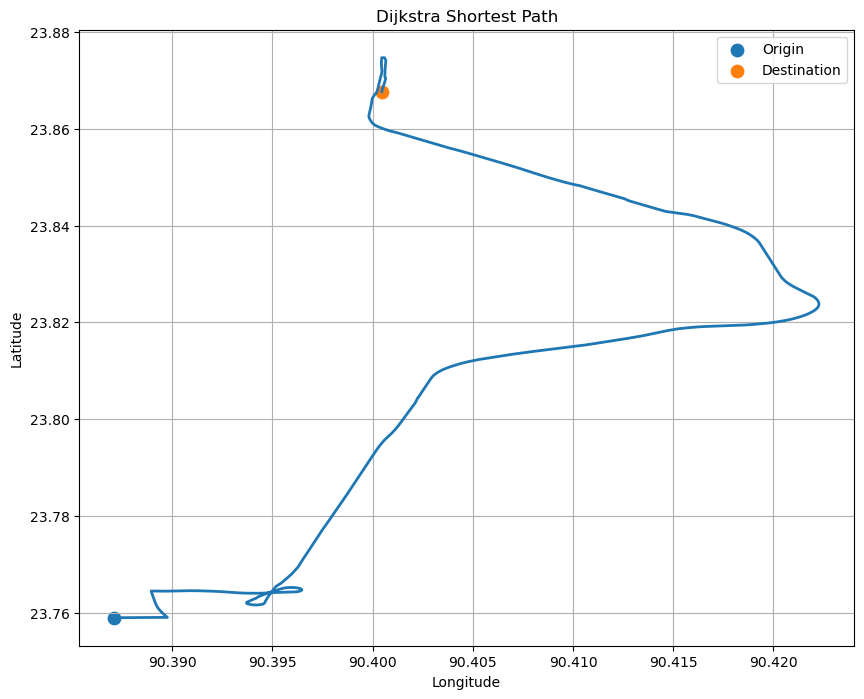

In [20]:
path_lons = [node[0] for node in dijkstra_path]
path_lats = [node[1] for node in dijkstra_path]

plt.figure(figsize=(10, 8))

plt.plot(path_lons, path_lats, linewidth=2)

plt.scatter(
    start_node[0],
    start_node[1],
    s=80,
    label="Origin"
)

plt.scatter(
    goal_node[0],
    goal_node[1],
    s=80,
    label="Destination"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Dijkstra Shortest Path")
plt.legend()
plt.grid(True)

plt.show()

>Farmgate → Uttara Sector 7 route-এর graph path

# Algorithm 2 — A*

>A* Dijkstra-এর মতো shortest path খুঁজে, কিন্তু destination পর্যন্ত estimated distance (heuristic) ব্যবহার করে search-কে goal-এর দিকে guide করে।
>আমাদের project-এ এর মূল উদ্দেশ্য হলো Dijkstra-এর তুলনায় কম node explore করে দ্রুত route বের করা।

### A* Heuristic

In [21]:
def heuristic(node, goal):
    """
    Estimate the remaining distance between two nodes
    using straight-line geographic distance.
    """

    return haversine_distance(node, goal)

### A* Algorithm

In [22]:
def astar_shortest_path(graph, start, goal):
    """
    Find the shortest path using A* algorithm.
    """

    g_score = {node: float("inf") for node in graph.nodes}
    f_score = {node: float("inf") for node in graph.nodes}

    previous = {node: None for node in graph.nodes}

    g_score[start] = 0
    f_score[start] = heuristic(start, goal)

    priority_queue = [(f_score[start], start)]

    while priority_queue:

        current_f, current_node = heapq.heappop(priority_queue)

        if current_node == goal:
            break

        if current_f > f_score[current_node]:
            continue

        for neighbor in graph.neighbors(current_node):

            edge_weight = graph[current_node][neighbor]["distance"]

            tentative_g = g_score[current_node] + edge_weight

            if tentative_g < g_score[neighbor]:

                previous[neighbor] = current_node
                g_score[neighbor] = tentative_g

                f_score[neighbor] = (
                    tentative_g
                    + heuristic(neighbor, goal)
                )

                heapq.heappush(
                    priority_queue,
                    (f_score[neighbor], neighbor)
                )

    # Reconstruct path
    path = []
    current = goal

    while current is not None:
        path.append(current)
        current = previous[current]

    path.reverse()

    if path[0] != start:
        return None, float("inf")

    return path, g_score[goal]

### Run A*

In [23]:
astar_path, astar_distance = astar_shortest_path(
    G,
    start_node,
    goal_node
)

if astar_path is not None:
    print("Path found!")
    print(f"Number of nodes: {len(astar_path)}")
    print(f"Total distance: {astar_distance:.2f} km")
else:
    print("No path found.")

Path found!
Number of nodes: 330
Total distance: 17.50 km


### Dijkstra vs A* Performance

In [24]:
import time

# Dijkstra
start_time = time.perf_counter()

dijkstra_path, dijkstra_distance = dijkstra_shortest_path(
    G,
    start_node,
    goal_node
)

dijkstra_time = time.perf_counter() - start_time


# A*
start_time = time.perf_counter()

astar_path, astar_distance = astar_shortest_path(
    G,
    start_node,
    goal_node
)

astar_time = time.perf_counter() - start_time


print("Algorithm Performance")
print("-" * 35)

print(f"Dijkstra distance : {dijkstra_distance:.2f} km")
print(f"Dijkstra time     : {dijkstra_time:.6f} sec")

print()

print(f"A* distance       : {astar_distance:.2f} km")
print(f"A* time           : {astar_time:.6f} sec")

Algorithm Performance
-----------------------------------
Dijkstra distance : 17.50 km
Dijkstra time     : 0.000473 sec

A* distance       : 17.50 km
A* time           : 0.000707 sec


>Current graph-এ A* faster হয়নি; বরং slower হয়েছে। কারণ graph মাত্র 330-node এবং single OSRM route geometry। এই scale-এ heuristic calculation-এর overhead-ই বেশি হয়ে যাচ্ছে।

# 6. Algorithm 3 — Multi-Criteria Route Optimization

A shortest-distance route is not always the best journey.

The Multi-Criteria Route Optimization algorithm evaluates routes using
multiple factors:

- Travel time
- Travel cost
- Number of transfers
- Walking distance

A weighted scoring function is used to select the most suitable route
for the passenger.

>শুধু shortest distance সবসময় best journey না। একজন passenger হয়তো ১ km বেশি পথ মেনে নেবে যদি এতে সময় কম, খরচ কম, transfer কম বা walking কম হয়। তাই এই algorithm একসাথে কয়েকটা criterion score করে overall best route নির্বাচন করবে।

### Route Score Function

In [25]:
def calculate_route_score(
    time,
    cost,
    transfers,
    walking_distance,
    weights=OBJECTIVE_WEIGHTS
):
    """
    Calculate a weighted score for a route.

    Lower score = better route.
    """

    score = (
        weights["time"] * time
        + weights["cost"] * cost
        + weights["transfers"] * transfers
        + weights["walking"] * walking_distance
    )

    return score

In [26]:
def calculate_route_score(
    time,
    cost,
    transfers,
    walking_distance,
    weights=OBJECTIVE_WEIGHTS
):
    """
    Calculate a weighted score for a route.
    Lower score = better route.
    """

    score = (
        weights["time"] * time
        + weights["cost"] * cost
        + weights["transfers"] * transfers
        + weights["walking"] * walking_distance
    )

    return score

### Sample Multimodal Routes

In [27]:
routes = pd.DataFrame([
    {
        "route": "Route A",
        "time": 35,
        "cost": 40,
        "transfers": 1,
        "walking_distance": 0.8
    },
    {
        "route": "Route B",
        "time": 42,
        "cost": 25,
        "transfers": 0,
        "walking_distance": 0.5
    },
    {
        "route": "Route C",
        "time": 30,
        "cost": 55,
        "transfers": 2,
        "walking_distance": 1.2
    }
])

routes

,route,time,cost,transfers,walking_distance
0,Route A,35,40,1,0.8
1,Route B,42,25,0,0.5
2,Route C,30,55,2,1.2


### Calculate Route Scores

In [28]:
routes["score"] = routes.apply(
    lambda row: calculate_route_score(
        time=row["time"],
        cost=row["cost"],
        transfers=row["transfers"],
        walking_distance=row["walking_distance"]
    ),
    axis=1
)

routes

,route,time,cost,transfers,walking_distance,score
0,Route A,35,40,1,0.8,25.770
1,Route B,42,25,0,0.5,26.075
2,Route C,30,55,2,1.2,26.480


### Select Best Route

In [29]:
best_route = routes.loc[routes["score"].idxmin()]

print("Best Route:", best_route["route"])
print(f"Score: {best_route['score']:.2f}")

Best Route: Route A
Score: 25.77


# Algorithm 4 — ETA Prediction

>Route distance জানলেই actual journey time জানা যায় না। ETA algorithm distance, route characteristics এবং available travel-time information ব্যবহার করে estimated journey time দেবে। এতে passenger শুধু shortest route নয়, কতক্ষণ লাগতে পারে সেটাও জানতে পারবে।

### Simple ETA Model

In [30]:
def predict_eta(distance_km, average_speed_kmph):
    """
    Estimate travel time in minutes
    using distance and average speed.
    """

    if average_speed_kmph <= 0:
        raise ValueError("Average speed must be greater than zero.")

    eta_hours = distance_km / average_speed_kmph
    eta_minutes = eta_hours * 60

    return eta_minutes

### Test ETA

In [31]:
distance = route["distance_km"]

average_speed = 25  # km/h

eta = predict_eta(
    distance,
    average_speed
)

print(f"Distance: {distance:.2f} km")
print(f"Average speed: {average_speed} km/h")
print(f"Predicted ETA: {eta:.2f} minutes")

Distance: 17.45 km
Average speed: 25 km/h
Predicted ETA: 41.88 minutes


### Final Route Summary

In [32]:
final_result = {
    "Origin": origin["name"],
    "Destination": destination["name"],
    "OSRM Distance (km)": round(route["distance_km"], 2),
    "Dijkstra Distance (km)": round(dijkstra_distance, 2),
    "A* Distance (km)": round(astar_distance, 2),
    "Estimated ETA (min)": round(eta, 2),
    "Recommended Route": best_route["route"],
    "Route Score": round(best_route["score"], 2)
}

final_result

{'Origin': 'Farmgate, Dhaka',
 'Destination': 'Uttara Sector 7, Dhaka',
 'OSRM Distance (km)': 17.45,
 'Dijkstra Distance (km)': 17.5,
 'A* Distance (km)': 17.5,
 'Estimated ETA (min)': 41.88,
 'Recommended Route': 'Route A',
 'Route Score': np.float64(25.77)}

### Display Final Recommendation

In [33]:
print("SMART TRANSIT JOURNEY RECOMMENDATION")
print("=" * 45)

print(f"From        : {origin['name']}")
print(f"To          : {destination['name']}")
print(f"Distance    : {route['distance_km']:.2f} km")
print(f"ETA         : {eta:.2f} minutes")
print(f"Best Route  : {best_route['route']}")
print(f"Route Score : {best_route['score']:.2f}")

SMART TRANSIT JOURNEY RECOMMENDATION
From        : Farmgate, Dhaka
To          : Uttara Sector 7, Dhaka
Distance    : 17.45 km
ETA         : 41.88 minutes
Best Route  : Route A
Route Score : 25.77


### Clean Final Result

In [34]:
final_result["Route Score"] = float(best_route["score"])

final_result

{'Origin': 'Farmgate, Dhaka',
 'Destination': 'Uttara Sector 7, Dhaka',
 'OSRM Distance (km)': 17.45,
 'Dijkstra Distance (km)': 17.5,
 'A* Distance (km)': 17.5,
 'Estimated ETA (min)': 41.88,
 'Recommended Route': 'Route A',
 'Route Score': 25.77}

# Evaluation

### Algorithm Comparison

In [35]:
comparison = pd.DataFrame([
    {
        "Algorithm": "Dijkstra",
        "Distance (km)": dijkstra_distance,
        "Execution Time (sec)": dijkstra_time
    },
    {
        "Algorithm": "A*",
        "Distance (km)": astar_distance,
        "Execution Time (sec)": astar_time
    }
])

comparison

,Algorithm,Distance (km),Execution Time (sec)
0,Dijkstra,17.495485,0.000473
1,A*,17.495485,0.000707


### Distance Difference

In [36]:
distance_difference = abs(
    dijkstra_distance - astar_distance
)

print(
    f"Distance difference between Dijkstra and A*: "
    f"{distance_difference:.4f} km"
)

Distance difference between Dijkstra and A*: 0.0000 km


### Execution Time Comparison

In [37]:
print("Execution Time Comparison")
print("=" * 35)

print(f"Dijkstra: {dijkstra_time:.6f} seconds")
print(f"A*:       {astar_time:.6f} seconds")

if dijkstra_time < astar_time:
    faster_algorithm = "Dijkstra"
else:
    faster_algorithm = "A*"

print(f"\nFaster Algorithm: {faster_algorithm}")

Execution Time Comparison
Dijkstra: 0.000473 seconds
A*:       0.000707 seconds

Faster Algorithm: Dijkstra


### Performance Difference

In [38]:
time_difference = abs(dijkstra_time - astar_time)

print(
    f"Execution time difference: "
    f"{time_difference:.6f} seconds"
)

Execution time difference: 0.000234 seconds


### Final Evaluation Summary

In [39]:
evaluation_summary = pd.DataFrame([
    {
        "Method": "OSRM",
        "Distance (km)": route["distance_km"],
        "ETA (min)": route["duration_min"],
        "Execution Time (sec)": None
    },
    {
        "Method": "Dijkstra",
        "Distance (km)": dijkstra_distance,
        "ETA (min)": eta,
        "Execution Time (sec)": dijkstra_time
    },
    {
        "Method": "A*",
        "Distance (km)": astar_distance,
        "ETA (min)": eta,
        "Execution Time (sec)": astar_time
    },
    {
        "Method": "Multi-Criteria",
        "Distance (km)": None,
        "ETA (min)": best_route["time"],
        "Execution Time (sec)": None
    }
])

evaluation_summary

,Method,Distance (km),ETA (min),Execution Time (sec)
0,OSRM,17.450100,14.713333,NaN
1,Dijkstra,17.495485,41.880240,0.000473
2,A*,17.495485,41.880240,0.000707
3,Multi-Criteria,NaN,35.000000,NaN


### Final Metrics

In [40]:
print("FINAL EVALUATION")
print("=" * 40)

print(f"OSRM Distance       : {route['distance_km']:.2f} km")
print(f"Dijkstra Distance   : {dijkstra_distance:.2f} km")
print(f"A* Distance         : {astar_distance:.2f} km")

print()

print(f"Dijkstra Time       : {dijkstra_time:.6f} sec")
print(f"A* Time             : {astar_time:.6f} sec")

print()

print(f"Recommended Route   : {best_route['route']}")
print(f"Route Score         : {float(best_route['score']):.2f}")
print(f"Estimated ETA       : {eta:.2f} min")

FINAL EVALUATION
OSRM Distance       : 17.45 km
Dijkstra Distance   : 17.50 km
A* Distance         : 17.50 km

Dijkstra Time       : 0.000473 sec
A* Time             : 0.000707 sec

Recommended Route   : Route A
Route Score         : 25.77
Estimated ETA       : 41.88 min


# 8. Conclusion

The Smart Transit prototype demonstrates an AI-assisted
multimodal journey planning workflow using open geospatial
and routing services.

### Key Findings

- OSRM provided the baseline road route.
- Dijkstra successfully found the shortest path in the constructed graph.
- A* produced the same shortest-path distance as Dijkstra.
- In the current small graph, Dijkstra was faster than A*.
- Multi-Criteria Optimization selected the route based on
  time, cost, transfers, and walking distance.
- The ETA component estimated journey duration using average speed.

### Final Outcome

The prototype combines API-based transportation data with
four core algorithms to support route search, route optimization,
and travel-time estimation.

### Limitation

The current graph is constructed from a single OSRM route geometry.
Therefore, the Dijkstra and A* comparison does not represent a
full city-wide road-network benchmark.

A larger OpenStreetMap-based transport graph and real historical
travel-time data would be required for a production-level system.

# 9. Limitations & Future Work

### Current Limitations

- The graph is constructed from a single OSRM route geometry rather than a complete city-wide road network.
- Therefore, the current Dijkstra vs. A* benchmark is a prototype comparison, not a full-scale routing benchmark.
- The ETA component is a **baseline average-speed estimator**, not a trained machine-learning model.
- The multimodal alternatives used in the current demonstration are sample routes and are not yet generated from a complete multimodal transit feed.
- The public API services should be used within their published usage policies and rate limits.

### Future Improvements

1. Build a larger OpenStreetMap-based transport graph.
2. Integrate real bus/metro or GTFS transit data where available.
3. Normalize multi-criteria features before applying weighted scoring.
4. Train the ETA component using historical travel-time data.
5. Evaluate routing algorithms on larger graphs and multiple origin-destination pairs.


# 10. Conclusion

The Smart Transit prototype demonstrates how open geospatial services can be combined with algorithmic route optimization to build a lightweight journey-planning system.

The four core components provide complementary capabilities:

- **Dijkstra** establishes a reliable shortest-path baseline.
- **A\*** provides heuristic-guided shortest-path search.
- **Multi-Criteria Optimization** considers passenger-oriented route preferences.
- **ETA Prediction** provides a simple travel-time estimate.

The current results validate the end-to-end prototype while also showing where a larger transport graph, real multimodal data, and historical travel-time data would be required for a more realistic system.
